In [17]:
%matplotlib widget
import inspect
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import torch
import warp as wp

from warpSPHCore import *
from warpSPHCore.util import generateNeighborTestData

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r, type(x).__name__, x))

def plot_scalar_field(ax, positions, values, title, *, cmap="viridis", marker_size=2, domain=None):
    sc = ax.scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=values.cpu(), cmap=cmap, s=marker_size)
    ax.figure.colorbar(sc, ax=ax, shrink=0.95)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")
    if domain is not None:
        ax.set_xlim(domain.min[0].item(), domain.max[0].item())
        ax.set_ylim(domain.min[1].item(), domain.max[1].item())
    return sc

def plot_vector_components(fig, axes, positions, tensor_field, title_prefix, *, marker_size=2, domain=None, cmap="RdBu_r"):
    component_titles = [(0, 0), (0, 1), (1, 0), (1, 1)]
    for ax, (row, col) in zip(axes.flat, component_titles):
        component = tensor_field[:, row, col]
        sc = ax.scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=component.cpu(), cmap=cmap, s=marker_size)
        ax.figure.colorbar(sc, ax=ax, shrink=0.95)
        ax.set_title(f"{title_prefix} [{row},{col}]")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_aspect("equal")
        if domain is not None:
            ax.set_xlim(domain.min[0].item(), domain.max[0].item())
            ax.set_ylim(domain.min[1].item(), domain.max[1].item())
        fig.colorbar(sc, ax=ax, shrink=0.95)

def make_jittered_particles(base_positions, base_supports, base_masses, base_kinds, jitter_scale, dx, device):
    jitter = jitter_scale * dx * torch.randn_like(base_positions)
    jittered_positions = (base_positions + jitter).contiguous()
    return ParticleState(
        positions=jittered_positions,
        supports=base_supports.contiguous(),
        masses=base_masses.contiguous(),
        densities=None,
        kinds=base_kinds,
    )


In [18]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx ** dim

warpOnly = False
periodic = True
field_mode = "periodic_sinusoidal"  # "linear" or "periodic_sinusoidal"
mask_edge_particles = True  # used for linear fields to hide the periodic jump at the boundaries
jitter = 0.05
linear_slope_x = 5.0
linear_slope_y = 0.0

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.Gather

markerSize = 8 if warpOnly else 2
gridVisualization = False
gridResolution = 128
dx = 2.0 / nx


In [19]:
positions, supports, _, domain, dx = generateNeighborTestData(
    nx, targetNumNeighbors, dim, periodic, device
)

masses = torch.full((positions.shape[0],), dx ** dim, device=device, dtype=positions.dtype)
kinds = torch.zeros(positions.shape[0], device=device, dtype=torch.int32)

particles = ParticleState(
    positions=positions.contiguous(),
    supports=supports.contiguous(),
    masses=masses.contiguous(),
    densities=None,
    kinds=kinds,
)

adjacency = radiusSearchCompactHashMap(
    particles,
    domain,
    mode=SupportScheme.SuperSymmetric,
)

densities = warpOperation(
    particles,
    OperationProperties(
        kernel=kernel,
        operation=WarpOperation.Density,
        supportMode=supportMode,
        operationMode=OperationDirection.AllToAll,
    ),
    domain,
    adjacency=adjacency,
)
particles.densities = densities

def make_scalar_field(x, y):
    if field_mode == "periodic_sinusoidal":
        return torch.sin(math.pi * x) * torch.cos(math.pi * y)
    return linear_slope_x * x + linear_slope_y * y + 10.0

def make_vector_field(x, y):
    if field_mode == "periodic_sinusoidal":
        # Divergence-free rotational field from stream function psi = sin(pi x) sin(pi y):
        # F = (dpsi/dy, -dpsi/dx), so curl(F) = -laplacian(psi) = 2*pi^2*sin(pi x)*sin(pi y).
        # (The previous F = (sin(pi x), cos(pi y)) had zero curl everywhere by construction,
        # so it never actually exercised the curl operator.)
        return torch.stack((
            math.pi * torch.sin(math.pi * x) * torch.cos(math.pi * y),
            -math.pi * torch.cos(math.pi * x) * torch.sin(math.pi * y),
        ), dim=1)
    return torch.stack((2.0 * x + y, -x + 0.5 * y), dim=1)

scalar_field = make_scalar_field(positions[:, 0], positions[:, 1])
vector_field = make_vector_field(positions[:, 0], positions[:, 1])

jittered_particles = make_jittered_particles(
    positions,
    supports,
    masses,
    kinds,
    jitter,
    dx,
    device,
)

jittered_adjacency = radiusSearchCompactHashMap(
    jittered_particles,
    domain,
    mode=SupportScheme.SuperSymmetric,
)

jittered_densities = warpOperation(
    jittered_particles,
    OperationProperties(
        kernel=kernel,
        operation=WarpOperation.Density,
        supportMode=supportMode,
        operationMode=OperationDirection.AllToAll,
    ),
    domain,
    adjacency=jittered_adjacency,
)
jittered_particles.densities = jittered_densities

apparent_area, crk_density, crk_state = computeCRKFactors(
    jittered_particles,
    domain,
    kernel,
    operationMode=OperationDirection.AllToAll,
    adjacency=jittered_adjacency,
)

if field_mode == "periodic_sinusoidal":
    plot_mask = torch.ones(positions.shape[0], dtype=torch.bool, device=positions.device)
else:
    plot_mask = torch.ones(positions.shape[0], dtype=torch.bool, device=positions.device)
    if mask_edge_particles:
        band = 4.0 * dx
        for axis_idx in range(dim):
            plot_mask = plot_mask & (positions[:, axis_idx] > domain.min[axis_idx] + band)
            plot_mask = plot_mask & (positions[:, axis_idx] < domain.max[axis_idx] - band)


/home/veldora/dev/warpSPHCore/src/warpSPHCore/radiusSearch/wp_compactHash.py:1122: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  periodicity = torch.tensor(domain.periodic if domain.periodic is not None else [False] * queryParticles.positions.shape[1], device=queryParticles.positions.device)


Vector curl shape: (16384, 1)
Vector curl shape: (16384, 1)
Vector curl mean abs error: 0.038009241223335266


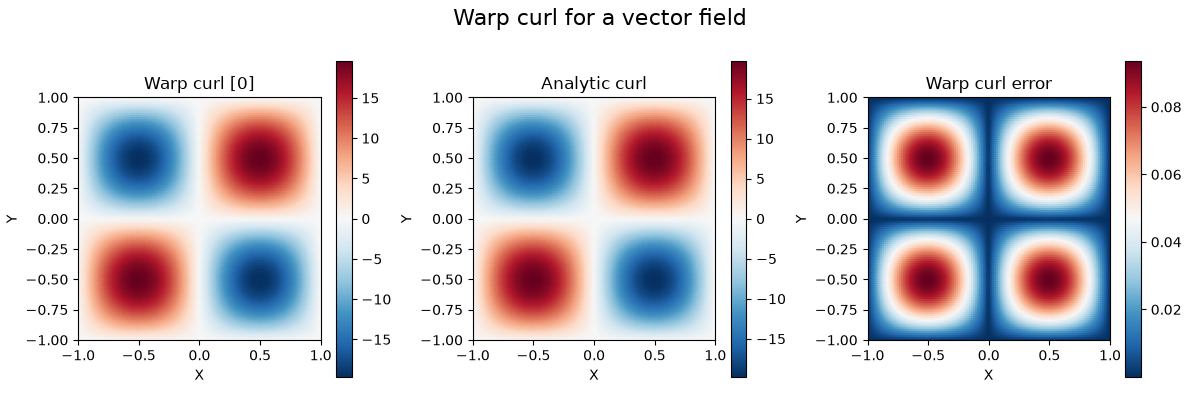

In [20]:
vector_curl_warp = warpOperation(
    particles,
    queryValues=vector_field,
    referenceValues=vector_field,
    operationProperties=OperationProperties(
        kernel=kernel,
        supportMode=supportMode,
        operation=WarpOperation.Curl,
        gradientMode=GradientScheme.Summation,
        operationMode=OperationDirection.AllToAll,
    ),
    adjacency=adjacency,
    domain=domain,
)
print("Vector curl shape:", tuple(vector_curl_warp.shape))

analytic_vector_curl = torch.zeros_like(vector_curl_warp)
if field_mode == "periodic_sinusoidal":
    # curl of F = (pi*sin(pi x)*cos(pi y), -pi*cos(pi x)*sin(pi y)) is 2*pi^2*sin(pi x)*sin(pi y).
    analytic_vector_curl = 2.0 * math.pi ** 2 * torch.sin(math.pi * positions[:, 0]) * torch.sin(math.pi * positions[:, 1])
else:
    analytic_vector_curl = torch.zeros_like(vector_curl_warp)
vector_curl_error = torch.abs(vector_curl_warp[:,0] - analytic_vector_curl)

fig, axis = plt.subplots(1, 3, figsize=(12, 4), squeeze=False)
sc = plot_scalar_field(axis[0, 0], positions[plot_mask], vector_curl_warp[:, 0][plot_mask], "Warp curl [0]", cmap="RdBu_r", marker_size=markerSize, domain=domain)
sc = plot_scalar_field(axis[0, 1], positions[plot_mask], analytic_vector_curl[:][plot_mask], "Analytic curl", cmap="RdBu_r", marker_size=markerSize, domain=domain)
sc = plot_scalar_field(axis[0, 2], positions[plot_mask], vector_curl_error[:][plot_mask], "Warp curl error", cmap="RdBu_r", marker_size=markerSize, domain=domain)
fig.suptitle("Warp curl for a vector field", fontsize=16)
fig.tight_layout()
print("Vector curl shape:", tuple(vector_curl_warp.shape))
print("Vector curl mean abs error:", vector_curl_error.mean().item())
